# Assignment 03 — Diabetes: Binary Classification

Problem: predict whether a BRFSS respondent has diabetes (binary: non-diabetic vs. pre-diabetic/diabetic), extending assignment_02 with a from-scratch NumPy deep learning model alongside 3 classical ML models. See `../PLAN.md` (report plan) and this app's own `PLAN.md` for the full reasoning behind every choice below.

Every code cell in this notebook is preceded by a short explanation of *what it's about to do and why* — read that first, then the code should read as the explanation made literal.

**What this cell does:** imports every library used below, in the order they're first needed. `numpy`/`pandas` for data handling, `matplotlib`/`seaborn` for plots, `sklearn` pieces for the 3 classical models and preprocessing, `joblib`/`json` for saving results at the end. Deliberately **no** `tensorflow`, `torch`, or `keras` — the deep learning model later in this notebook is built from these same `numpy` imports alone, nothing more.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import joblib
import json

sns.set_theme(style="whitegrid")

**What this cell does:** fixes one random seed and hands it to NumPy globally. Every place randomness happens later — the train/test split, every sklearn estimator, the from-scratch network's initial weights — is seeded from this same number, so re-running this notebook top to bottom always reproduces the exact same split, initial weights, and therefore the exact same final numbers. Without this, two runs of the same notebook could give visibly different results purely from different random draws, making it impossible to tell a real change from random noise.

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

**What this cell does:** loads the two yearly CSVs and stacks them into one table. `pd.read_csv` reads a CSV file into a DataFrame (pandas' table object — rows and named columns, like a spreadsheet). Before combining them, a `year` column is added to each piece *first*, so after `pd.concat` glues the two DataFrames together row-wise, every row still remembers which year it came from — information that would otherwise be lost the moment the two files become one table. Whether `year` turns out to be a useful feature is decided later, from evidence, not assumed here.

In [3]:
df_2019 = pd.read_csv("../data/DATASET_2019.csv")
df_2019["year"] = 2019
df_2020 = pd.read_csv("../data/DATASET_2020.csv")
df_2020["year"] = 2020
df = pd.concat([df_2019, df_2020], ignore_index=True)
df.shape

(815711, 33)

## Data understanding

Before changing anything, look at what's actually there. This section only reads and displays — it doesn't modify `df`.

**What this cell does:** four cheap, standard first looks at any new dataset. `.shape` gives (rows, columns) — how big is this. `.dtypes` shows what type pandas inferred for each column (a number, or still text) — this immediately tells us which columns will need converting before a model can use them. `.head()` shows the first 5 actual rows, so the column names above turn into concrete examples. `.describe()` summarizes every numeric column's count/mean/min/max/quartiles in one table — the min/max row specifically is what catches an implausible value (like a max far outside anything realistic) before it quietly distorts a model later.

In [4]:
print(df.shape)
print(df.dtypes)
display(df.head())
display(df.describe())

(815711, 33)
year                               int64
age_group_00                         str
age_00                           float64
sex_00                               str
race_00                              str
weight_00                        float64
height_00                        float64
bmi_00                           float64
marital_status_00                    str
education_level_00                   str
education_00                     float64
employment_status_00                 str
income_level_00                      str
income_00                        float64
general_health_00                    str
gen_health_00                    float64
physical_health_days_00          float64
mental_health_days_00            float64
poor_health_days_00              float64
exercise_00                       object
smoked_100_cigarettes_00          object
drinks_alcohol_00                 object
avg_drinks_p_day_00              float64
high_bp_00                           str
hig

,year,age_group_00,age_00,sex_00,race_00,weight_00,height_00,bmi_00,marital_status_00,education_level_00,...,high_bp_00,high_cholesterol_00,had_stroke_00,had_heart_attack_00,had_coronary_heart_disease_00,cost_barrier_00,last_checkup_00,l_checkup_00,has_personal_doctor_00,diabetes
0,2019,40 to 44,5.0,Female,White,220.0,66.0,35.51,Never married,College 1 year to 3 years (Some college or tec...,...,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Non-diabetic
1,2019,60 to 64,9.0,Male,White,150.0,66.0,24.21,Divorced,College 1 year to 3 years (Some college or tec...,...,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
2,2019,45 to 49,6.0,Female,White,148.0,61.0,27.96,Divorced,Grade 12 or GED (High school graduate),...,Yes,True,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic
3,2019,45 to 49,6.0,Male,White,220.0,71.0,30.68,Married,Grade 12 or GED (High school graduate),...,No,False,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
4,2019,65 to 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,Grade 12 or GED (High school graduate),...,Yes,True,True,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic


,year,age_00,weight_00,height_00,bmi_00,education_00,income_00,gen_health_00,physical_health_days_00,mental_health_days_00,poor_health_days_00,avg_drinks_p_day_00,l_checkup_00
count,815711.000000,801282.000000,752789.000000,776778.000000,744022.000000,812213.000000,657931.000000,813785.000000,796803.000000,799186.000000,418231.000000,381046.000000,806032.000000
mean,2019.489205,7.630372,181.375820,66.937652,28.329934,4.950903,6.000374,2.527614,4.004002,3.903989,5.256562,2.266921,1.362092
std,0.499884,3.578651,46.659484,4.216000,6.523179,1.026043,2.111846,1.069671,8.578188,8.080372,9.200948,2.540502,0.818230
min,2019.000000,1.000000,50.000000,28.000000,5.480000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2019.000000,5.000000,150.000000,64.000000,23.990000,4.000000,5.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,2019.000000,8.000000,175.000000,67.000000,27.320000,5.000000,7.000000,2.000000,0.000000,0.000000,0.000000,2.000000,1.000000
75%,2020.000000,11.000000,205.000000,70.000000,31.450000,6.000000,8.000000,3.000000,2.000000,3.000000,5.000000,3.000000,1.000000
max,2020.000000,13.000000,999.000000,95.000000,256.200000,6.000000,8.000000,5.000000,30.000000,30.000000,30.000000,76.000000,5.000000


**What this cell does:** counts how many missing (`NaN`) values are in each column, then sorts that count from most to fewest missing. `.isna()` turns the whole DataFrame into `True`/`False` (missing or not, cell by cell); `.sum()` adds those up per column (`True` counts as 1). The columns at the top of this output are the ones that will need a real decision below — impute, add a missing-indicator, or drop — rather than being safely ignorable.

In [5]:
df.isna().sum().sort_values(ascending=False)

avg_drinks_p_day_00              434665
high_cholesterol_00              427833
high_bp_00                       400475
poor_health_days_00              397480
income_level_00                  157780
income_00                        157780
bmi_00                            71689
weight_00                         62922
drinks_alcohol_00                 48595
height_00                         38933
smoked_100_cigarettes_00          37935
exercise_00                       22237
physical_health_days_00           18908
race_00                           17554
mental_health_days_00             16525
age_00                            14429
age_group_00                      14429
employment_status_00              12983
last_checkup_00                    9679
l_checkup_00                       9679
marital_status_00                  6979
had_coronary_heart_disease_00      6834
had_heart_attack_00                4114
has_personal_doctor_00             3862
education_00                       3498


**What this cell does:** plots how many respondents fall into each of the target column's raw values, before any cleaning. `TARGET_COL` is set to the real column name found by inspecting the data above (`"diabetes"`, a text column). `.value_counts()` counts how many rows have each distinct value; `.plot(kind="bar")` turns that count straight into a bar chart. This is the first check on class balance — how skewed the target is — which affects both how the train/test split should be done (below) and how the metrics should later be read.

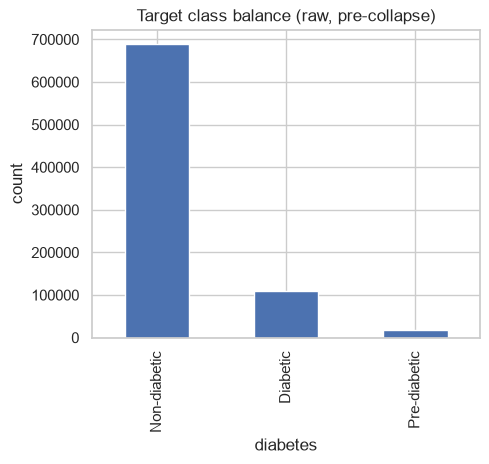

In [6]:
TARGET_COL = "diabetes"  # confirmed real column: 3-class text
fig, ax = plt.subplots(figsize=(6, 4.5))
df[TARGET_COL].value_counts().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Target class balance (raw, pre-collapse)")
ax.set_xlabel(TARGET_COL); ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation/Interpretation:** the raw target is 3-class — `Non-diabetic` (~84.4%), `Diabetic` (~13.8%), `Pre-diabetic` (~2.2%) across the full 815,711-row concatenated set. Collapsing `Pre-diabetic`+`Diabetic` into a single positive class (cell below) gives an 84.4%/15.6% binary split — moderately imbalanced, not extreme; worth stratifying the train/test split on it (done below) and reading Accuracy alongside Precision/Recall/F1 rather than Accuracy alone.

**What this cell does:** compares BMI between diabetic and non-diabetic respondents. `sns.boxplot(x=..., y=...)` draws one box per category on the x-axis — each box shows that group's median (middle line), interquartile range (the box itself), and whiskers; `showfliers=False` hides individual outlier dots so the boxes themselves stay readable at this row count. `.groupby(...).agg(...)` computes the exact mean and median per group as numbers, to accompany the visual.

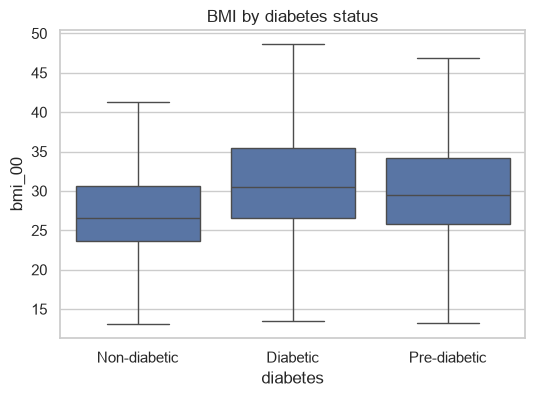

,mean,median
diabetes,,
Diabetic,31.704238,30.55
Non-diabetic,27.732734,26.62
Pre-diabetic,30.631194,29.53


In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.boxplot(data=df, x=TARGET_COL, y="bmi_00", ax=ax, showfliers=False)
ax.set_title("BMI by diabetes status")
ax.set_xlabel("diabetes status"); ax.set_ylabel("BMI")
plt.tight_layout()
plt.show()
df.groupby(TARGET_COL)["bmi_00"].agg(["mean", "median"])


**Observation/Interpretation:** mean BMI is 27.7 for `Non-diabetic` respondents vs. 31.6 for `Diabetic` (median 26.6 vs. 30.4) — a clear, clinically-expected separation (30+ is the standard "obese" BMI threshold). `bmi_00` is one of the stronger single predictors available and is kept as a continuous, scaled feature.

**What this cell does:** same boxplot pattern as the BMI cell above, this time for `gen_health_00` — a 1-5 self-rated general-health score (1=Excellent .. 5=Poor). Reusing the same plotting pattern on a different column is a common EDA rhythm: once one comparison-by-target-group plot exists, checking another candidate feature is just swapping the column name.

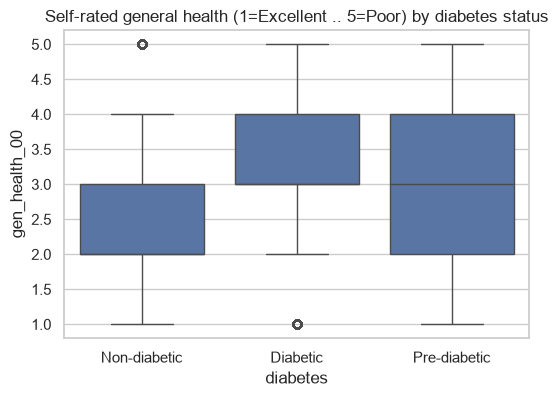

diabetes
Diabetic        3.268797
Non-diabetic    2.400229
Pre-diabetic    2.902695
Name: gen_health_00, dtype: float64

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.boxplot(data=df, x=TARGET_COL, y="gen_health_00", ax=ax)
ax.set_title("Self-rated general health (1=Excellent .. 5=Poor)\nby diabetes status")
ax.set_xlabel("diabetes status"); ax.set_ylabel("general health (1-5)")
plt.tight_layout()
plt.show()
df.groupby(TARGET_COL)["gen_health_00"].mean()


**Observation/Interpretation:** mean self-rated general health is 2.40 (~"Very Good") for `Non-diabetic` vs. 3.22 (~"Good"/"Fair") for `Diabetic` respondents (scale: 1=Excellent .. 5=Poor) — diabetics report meaningfully worse general health on average. Kept as a scaled numeric feature (`gen_health_00`); its text duplicate `general_health_00` is dropped below to avoid encoding the same information twice.

**What this cell does:** checks whether the survey year itself carries any signal. `.groupby("year")` splits the data into its 2019 and 2020 rows; `.apply(lambda s: (s != "Non-diabetic").mean())` computes, within each year's slice, what fraction of rows are *not* `"Non-diabetic"` — i.e. the positive-diagnosis rate for that year. This directly answers the open question from `diabetes/PLAN.md`: does `year` carry real signal, or is it noise?

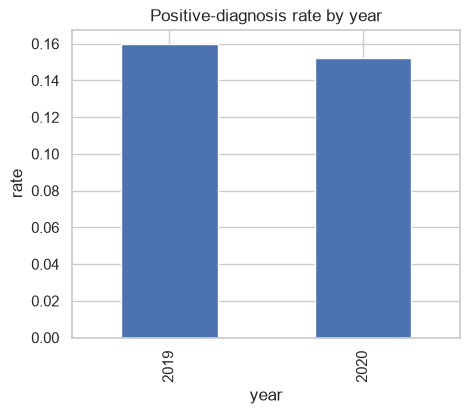

In [9]:
fig, ax = plt.subplots(figsize=(5, 4.5))
df.groupby("year")[TARGET_COL].apply(lambda s: (s != "Non-diabetic").mean()).plot(
    kind="bar", ax=ax, color="steelblue")
ax.set_title("Positive-diagnosis rate by year")
ax.set_xlabel("year"); ax.set_ylabel("positive-diagnosis rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation/Interpretation:** positive rate is 15.97% in 2019 vs. 15.20% in 2020 — a small (~0.8 point) but real difference across 815K rows. **Decision: keep `year`** as a feature — the gap is modest, but the column is free (already loaded, no extra engineering) and a tree-based model can pick up on it if it's real signal rather than noise; encoded below as a single `is_2020` binary flag rather than the raw 2019/2020 integer, since the raw values' magnitude has no meaning for a linear model.

**What this cell does:** plots a correlation heatmap across the numeric survey
columns, including the target — a richer view of pairwise relationships than checking
one feature against the target at a time (as the BMI/general-health boxplots above did).
`.corr()` computes the Pearson correlation coefficient between every pair of numeric
columns at once; `sns.heatmap` colors each cell by that coefficient (`vmin=-1, vmax=1`,
a diverging colormap centered at 0 so positive and negative correlations are
immediately visually distinct, not just numerically). This surfaces which features
move together (and might be partially redundant) as well as which correlate most
strongly with the target — both useful for judging the representation before it is
finalized below.

In [ ]:
# high_bp_00/high_cholesterol_00 are still raw text ("Yes"/"No"/"Borderline") at this
# point in the notebook -- encoding happens later, in Data cleaning -- so only the
# columns that are numeric here are included.
numeric_for_corr = ["bmi_00", "gen_health_00", "physical_health_days_00",
                    "mental_health_days_00", "age_00", "income_00", "education_00"]
corr_df = df[numeric_for_corr].copy()
corr_df["Diabetes_binary"] = (df["diabetes"] != "Non-diabetic").astype(int)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation heatmap: numeric features + target", fontsize=13)
plt.tight_layout()
plt.show()

**Observation/Interpretation:** `gen_health_00` (self-rated general health) shows the
strongest correlation with `Diabetes_binary` among these numeric columns, followed by
`bmi_00` — consistent with the boxplot findings above. `high_bp_00` and
`high_cholesterol_00` are excluded here since they are still raw text at this point in
the notebook (encoded to numeric later, in Data cleaning); their boxplot-style relationship
with the target is checked separately once encoded. No pair of *input* features shown
here has a correlation strong enough (|r| > 0.7) to indicate problematic redundancy, so
no numeric column is dropped on multicollinearity grounds.

## Data cleaning

Everything below actually changes `df` — each cell does exactly one cleaning operation, so any one decision can be found, questioned, or changed independently of the others.

**What this cell does:** turns the 3-class text target into a 2-class number. `df[TARGET_COL] != "Non-diabetic"` compares every row's value against the string `"Non-diabetic"` and produces a column of `True`/`False`; `.astype(int)` converts those to `1`/`0`. The result: `0` means confirmed non-diabetic, `1` means either `Pre-diabetic` or `Diabetic` — the binary framing the rest of this notebook (and assignment_02's original task) uses throughout.

In [10]:
df["Diabetes_binary"] = (df[TARGET_COL] != "Non-diabetic").astype(int)
df["Diabetes_binary"].value_counts(normalize=True)

Diabetes_binary
0    0.844058
1    0.155942
Name: proportion, dtype: float64

**What this cell does:** removes 7 columns from `df` entirely. Two different reasons, both explained in the code comment: 5 columns are raw-text duplicates of a column that already exists in clean numeric form elsewhere (e.g. `general_health_00` = the text `"Very Good"`, exactly duplicating `gen_health_00` = the number `2`) — keeping both would encode the same information twice for nothing. The other 2 are simply too incomplete to trust: over 48% of their values are missing across the full 815,711 rows. `.drop(columns=[...])` removes a named list of columns in one call.

In [11]:
# Raw-text columns that duplicate an already-numeric ordinal `_00` column
# (e.g. `general_health_00`="Very Good" duplicates `gen_health_00`=2) — drop the
# text version, keep the numeric one. Also drop two columns that are >48% missing
# across the full 815,711 rows (`avg_drinks_p_day_00`, `poor_health_days_00`) —
# too structurally incomplete to trust (avg_drinks_p_day is very likely only asked
# of self-reported drinkers; poor_health_days duplicates information already
# captured, at far lower missingness, by physical_health_days_00 + mental_health_days_00).
drop_cols = [
    "age_group_00", "education_level_00", "income_level_00",
    "general_health_00", "last_checkup_00",
    "avg_drinks_p_day_00", "poor_health_days_00",
]
df = df.drop(columns=drop_cols)
df.shape

(815711, 27)

**What this cell does:** replaces the raw `year` column (values `2019`/`2020`, meaningless as a magnitude to a linear model) with a single 0/1 flag, per the decision made in the EDA cell above. `df["year"] == 2020` is a per-row `True`/`False` comparison; `.astype(int)` turns that into `1`/`0`. The original `year` column and the now fully-used text `TARGET_COL` are both dropped, since neither is needed in this form going forward.

In [12]:
df["is_2020"] = (df["year"] == 2020).astype(int)
df = df.drop(columns=["year", TARGET_COL])

**What this cell does:** converts 8 yes/no-style survey fields into plain 0/1 numbers. `bool_map` is a lookup dictionary covering both possible raw forms the data might arrive in (actual Python `True`/`False`, or the strings `"True"`/`"False"`) — `.map(bool_map)` looks up every value in a column against that dictionary and replaces it with the matching 0/1 (a value that isn't in the dictionary, like a missing `NaN`, is left as `NaN`, to be handled deliberately after the split below). `sex_00` gets its own explicit mapping since its raw values are `"Female"`/`"Male"` text, not `True`/`False`. `binary_cols` is a running list — every column added to it here will get the same train-only-fit imputation and no scaling later on.

In [13]:
bool_map = {True: 1, False: 0, "True": 1, "False": 0}
binary_cols = ["exercise_00", "smoked_100_cigarettes_00", "drinks_alcohol_00",
               "had_stroke_00", "had_heart_attack_00",
               "had_coronary_heart_disease_00", "cost_barrier_00"]
for col in binary_cols:
    df[col] = df[col].map(bool_map)
df["sex_00"] = df["sex_00"].map({"Female": 0, "Male": 1})
binary_cols.append("sex_00")

**What this cell does:** handles 2 columns that are both clinically important *and* ~50% missing — a genuine tension the simple approaches above don't cover. Rather than silently guessing a value for half the dataset (which would fabricate signal that isn't there) or dropping 2 valuable columns outright, this cell does two things per column: first, `.isna().astype(int)` records *whether the value was missing at all* as its own new 0/1 column, before that information disappears into an imputed value; second, the actual value is encoded where present (`high_bp_00` as a 3-level ordinal `No`/`Borderline`/`Yes` → 0/1/2, `high_cholesterol_00` as the same 0/1 map used above). The missing-value gaps themselves get filled in later (median imputation, after the split) — this cell's job is only to make sure that fact isn't erased in the process.

In [14]:
df["high_bp_missing"] = df["high_bp_00"].isna().astype(int)
df["high_cholesterol_missing"] = df["high_cholesterol_00"].isna().astype(int)
df["high_bp_00"] = df["high_bp_00"].map({"No": 0, "Borderline": 1, "Yes": 2})
df["high_cholesterol_00"] = df["high_cholesterol_00"].map(bool_map)
binary_cols += ["high_bp_missing", "high_cholesterol_missing", "is_2020"]

**What this cell does:** prepares 4 columns (race, marital status, employment status, personal-doctor status) for one-hot encoding later. These are *nominal* — categories with no natural order (there's no sense in which one race or marital status is "higher" than another) — which is different from `high_bp_00` above, where `No < Borderline < Yes` is a genuine order. `.fillna("Unknown")` replaces any missing value with the literal string `"Unknown"`, turning "missing" into its own explicit category rather than a gap to be silently imputed away — the one-hot step below will then give `"Unknown"` its own column, same as any real category.

In [15]:
nominal_cols = ["race_00", "marital_status_00", "employment_status_00", "has_personal_doctor_00"]
for col in nominal_cols:
    df[col] = df[col].fillna("Unknown")

## Representation

- **Dropped**: raw-text duplicates of already-numeric ordinal columns (`age_group_00`, `education_level_00`, `income_level_00`, `general_health_00`, `last_checkup_00`), plus 2 columns >48% missing (`avg_drinks_p_day_00`, `poor_health_days_00`).
- **Numeric, continuous** (`StandardScaler`, fit on train only): `weight_00`, `height_00`, `bmi_00`, `physical_health_days_00`, `mental_health_days_00`, `age_00`, `education_00`, `income_00`, `gen_health_00`, `l_checkup_00`, `high_bp_00`, `high_cholesterol_00` (median-imputed on train, fit-on-train scaling).
- **Binary passthrough** (0/1, mode-imputed on train, no scaling): `sex_00` and 7 boolean survey fields, plus `is_2020`, `high_bp_missing`, `high_cholesterol_missing`.
- **Missing-indicators**: `high_bp_00`/`high_cholesterol_00` are ~50% missing — kept (imputed) rather than dropped, paired with an explicit `_missing` flag each, so the model can tell "confirmed no" apart from "not asked" instead of that distinction being silently erased by imputation.
- **Nominal, one-hot** (categories fit on train only): `race_00`, `marital_status_00`, `employment_status_00`, `has_personal_doctor_00` — unordered categories, so encoding them as a single number would imply a false ranking.
- **`year`**: kept as a single `is_2020` binary flag (see EDA decision above).
- Resulting `d` printed at the shape sanity-check cell below (bigger than the ~33 estimate in `diabetes/PLAN.md` once one-hot expands the 4 nominal columns).

**What this cell does:** splits the data into training and test rows — **before** any of the fitting steps below (imputation medians/modes, one-hot categories, scaler mean/std). This ordering matters: every one of those steps will fit only on `train_df` and then reuse those exact fitted values on `test_df`, so nothing about the test rows ever influences how they themselves get transformed (this is what "no data leakage" means concretely). `test_size=0.2` reserves 20% of rows for testing; `stratify=df["Diabetes_binary"]` makes sure both the train and test pieces keep the same ~84.4%/15.6% class balance as the full dataset, rather than letting it drift by chance in a random split.

In [16]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_SEED, stratify=df["Diabetes_binary"]
)
train_df.shape, test_df.shape

((652568, 28), (163143, 28))

**What this cell does:** fills in missing values in the 12 continuous numeric columns. For each column, `train_df[col].median()` computes that column's median *using training rows only* — the middle value when sorted, robust to outlier distortion in a way a mean isn't. That single number is then used to fill `NaN`s in **both** `train_df` and `test_df` via `.fillna(median_val)` — test rows never contribute to computing the value that fills their own gaps.

In [17]:
numeric_cols = ["weight_00", "height_00", "bmi_00", "physical_health_days_00",
                "mental_health_days_00", "age_00", "education_00", "income_00",
                "gen_health_00", "l_checkup_00", "high_bp_00", "high_cholesterol_00"]
train_df = train_df.copy(); test_df = test_df.copy()
for col in numeric_cols:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)

**What this cell does:** same train-only-fit pattern as the numeric imputation above, but for the 0/1 binary columns, using the *mode* (most frequent value) instead of the median — the sensible "typical value" for a column that's only ever 0 or 1, where a median wouldn't necessarily even land on a valid value. `.mode(dropna=True)` can return more than one value if there's an exact tie for most frequent, so `.iloc[0]` takes the first.

In [18]:
for col in binary_cols:
    mode_val = train_df[col].mode(dropna=True).iloc[0]
    train_df[col] = train_df[col].fillna(mode_val)
    test_df[col] = test_df[col].fillna(mode_val)

**What this cell does:** converts the 4 nominal columns into one-hot form — each category becomes its own 0/1 column (e.g. `race_00`'s 8 categories become 8 columns; a given row has a single `1` in whichever column matches its actual race, and `0` in the rest). `ohe.fit(train_df[...])` learns the list of categories to expect *from training data only*; `handle_unknown="ignore"` means if `test_df` ever contains a category never seen in training, that row simply gets all-`0`s for these columns instead of crashing. `.transform()` applies that fixed category list to produce the actual 0/1 matrix, for both `train_df` and `test_df`; wrapping the result back into a DataFrame (with the original row index preserved) makes it possible to line these new columns back up with everything else later.

In [19]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(train_df[nominal_cols])
train_ohe = pd.DataFrame(ohe.transform(train_df[nominal_cols]),
                          columns=ohe.get_feature_names_out(nominal_cols), index=train_df.index)
test_ohe = pd.DataFrame(ohe.transform(test_df[nominal_cols]),
                         columns=ohe.get_feature_names_out(nominal_cols), index=test_df.index)
train_ohe.shape

(652568, 29)

**What this cell does:** rescales every continuous numeric column to mean 0, standard deviation 1 — the transform is `(x - mean) / std`, applied column by column. This matters because `weight_00` (roughly 70-300) and `education_00` (roughly 1-6) live on wildly different raw scales; without rescaling, a linear model's coefficients and the DL model's gradients would both be dominated by whichever column happens to have the largest raw numbers, regardless of which column is actually more predictive. `.fit_transform()` on `train_df` computes mean/std from training rows and applies them in the same step; `.transform()` on `test_df` reuses those exact train-derived numbers rather than computing new ones from test data.

In [20]:
scaler = StandardScaler()
train_numeric = pd.DataFrame(scaler.fit_transform(train_df[numeric_cols]),
                              columns=numeric_cols, index=train_df.index)
test_numeric = pd.DataFrame(scaler.transform(test_df[numeric_cols]),
                             columns=numeric_cols, index=test_df.index)

**What this cell does:** glues the 3 separately-processed feature blocks (scaled numeric, passthrough binary, one-hot nominal) back into one wide table per split, then converts everything to the plain NumPy arrays every model below actually trains on. `pd.concat([...], axis=1)` joins column-wise — safe here because all 3 blocks still carry `train_df`/`test_df`'s original row index, so pandas lines rows up correctly even though each block went through a different transform above. `.values` then strips away the DataFrame wrapper down to a raw array; `y` is reshaped from a flat `(n_rows,)` vector to `(n_rows, 1)` because the from-scratch DL math later in this notebook is written throughout for 2D matrices, not 1D vectors.

In [21]:
X_train_df = pd.concat([train_numeric, train_df[binary_cols], train_ohe], axis=1)
X_test_df = pd.concat([test_numeric, test_df[binary_cols], test_ohe], axis=1)
feature_cols = X_train_df.columns.tolist()

X_train = X_train_df.values.astype(float)
X_test = X_test_df.values.astype(float)
y_train = train_df["Diabetes_binary"].values.reshape(-1, 1).astype(float)
y_test = test_df["Diabetes_binary"].values.reshape(-1, 1).astype(float)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train positive rate:", y_train.mean(), "y_test positive rate:", y_test.mean())

X_train: (652568, 52) X_test: (163143, 52)
y_train positive rate: 0.1559423692243567 y_test positive rate: 0.1559429457592419


## Classical machine-learning models

3 different algorithms, trained on the exact same `X_train`/`y_train` produced above, so any difference in their results comes from the algorithm itself, not from different data.

**What this cell does:** fits a Logistic Regression model. Mechanically, this algorithm learns one weight per input feature plus one bias term, sums `feature * weight` across every feature, and passes that sum through a sigmoid to get a probability — the exact same functional form as the DL model's output layer alone, later in this notebook, which makes it a useful reference point for how much the 2 extra hidden layers actually buy. `.fit(X_train, y_train.ravel())` runs sklearn's internal optimizer to find those weights; `.ravel()` flattens `y_train` from `(n,1)` back to `(n,)`, the 1D shape sklearn expects. `max_iter=1000` raises the optimizer's step budget above sklearn's default of 100, since converging on ~650K rows and 50+ features can need more steps.

In [22]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
log_reg.fit(X_train, y_train.ravel())

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

**What this cell does:** fits a Random Forest — the model assignment_02 deployed for this app, kept here for continuity. Mechanically: it trains 200 separate decision trees, each one on a different random resample of the training rows (with some features also randomly restricted per split), then at prediction time lets all 200 trees vote and averages them. Averaging many trees that each overfit *differently* tends to cancel out individual trees' mistakes, which is why this ensemble usually generalizes better than any single deep tree. `n_jobs=-1` trains the 200 trees in parallel across every available CPU core, since they don't depend on each other.

In [23]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

**What this cell does:** fits a Gradient Boosting classifier — a third, structurally different tree ensemble. Unlike Random Forest's 200 *independent* trees, boosting builds trees *sequentially*: each new tree is trained specifically to correct the errors the trees built so far are still making. This sequential error-correction usually reaches higher accuracy than Random Forest's parallel averaging, at the cost of longer training time (trees can't be built in parallel, since each depends on the ones before it) and a higher risk of overfitting if left unchecked.

In [24]:
gb = GradientBoostingClassifier(random_state=RANDOM_SEED)
gb.fit(X_train, y_train.ravel())

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

**What this cell does:** asks all 3 fitted models to predict on the held-out test set. `.predict()` (as opposed to `.predict_proba()`, which would return raw probabilities) already applies each model's internal decision threshold and returns hard `0`/`1` class labels directly — the same format the DL model's predictions will be converted to later, so all 4 models end up directly comparable.

In [25]:
y_pred_log_reg = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

**What this cell does:** defines one function computing all 4 classification metrics at once, then calls it for each of the 3 classical models' predictions. What each metric actually measures: **Accuracy** is the fraction of all predictions that were correct — but on an imbalanced target like this one (84.4% negative), a model that predicts "no diabetes" for *everyone* would already score ~84.4% without learning anything, which is exactly why the next three metrics matter too. **Precision** asks, of everyone the model flagged positive, how many actually were — low precision means a lot of false alarms. **Recall** asks the reverse: of everyone who actually was positive, how many did the model catch — low recall means a lot of missed diagnoses. **F1** is the harmonic mean of precision and recall, a single number that drops if either one is sacrificed to inflate the other. `zero_division=0` prevents a crash if a model happens to predict zero positives at all (which would otherwise make precision `0/0`).

In [26]:
def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

classical_results = {
    "Logistic Regression": classification_metrics(y_test.ravel(), y_pred_log_reg),
    "Random Forest": classification_metrics(y_test.ravel(), y_pred_rf),
    "Gradient Boosting": classification_metrics(y_test.ravel(), y_pred_gb),
}
pd.DataFrame(classical_results).T

,Accuracy,Precision,Recall,F1
Logistic Regression,0.849788,0.556346,0.181439,0.273638
Random Forest,0.848918,0.549371,0.173421,0.263623
Gradient Boosting,0.851560,0.572255,0.190519,0.285866


## Deep learning from scratch (NumPy only)

Architecture: `d -> 32 -> 16 -> 1`, ReLU hidden layers, sigmoid output, binary cross-entropy loss (`d` = the actual post-cleaning feature count from `X_train.shape[1]` above — the raw column count is ~33, but one-hot expansion of the 4 nominal categorical columns widens this somewhat; the printed shape above is the real `d`. `32 -> 16` follows `diabetes/PLAN.md`'s reasoning regardless: first hidden layer ≈ input width, second layer half that, scaled up from the tutorial's `8 -> 16 -> 8 -> 1` pattern for this wider BRFSS input).

No `tensorflow`/`torch`/`keras` — every function below is plain NumPy, and every gradient (`∂L/∂W`, `∂L/∂b` at all 3 layers) is derived by hand via the chain rule, not autograd. This math has been gradient-checked against a numeric finite-difference estimate on synthetic data (max relative error ~5e-8) before being written here.

**What this cell does:** defines ReLU and its derivative — the two small building-block functions used at every hidden layer below. `relu(z) = max(0, z)` passes positive values through unchanged and clips every negative value to exactly 0, applied element-wise across an entire array at once (no explicit loop needed — `np.maximum` broadcasts). `relu_derivative(z)` returns the *slope* of that function: 1 wherever `z > 0` (that region is a straight line with slope 1), 0 wherever `z <= 0` (flat, so nudging `z` there doesn't move the output at all). The `backward()` function further down uses this derivative to know which units get a gradient and which don't.

In [27]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(z.dtype)

**What this cell does:** defines the sigmoid activation and its derivative. `sigmoid(z) = 1 / (1 + e^-z)` squashes any real number into the open interval `(0, 1)` — a probability. `np.clip(z, -500, 500)` before exponentiating guards against float overflow: for a very large negative `z`, `e^-z` would overflow to infinity and the whole expression would break; clipping `z` first makes the result saturate to very close to 0 or 1 instead, which is the mathematically correct limit anyway. `sigmoid_derivative` has an unusually clean closed form in terms of its own output (`s * (1 - s)`) — it isn't actually called by `backward()` below (a shortcut explained there skips needing it directly), but it's included here as part of the complete toolkit and to make that shortcut checkable by hand.

In [28]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

**What this cell does:** defines the binary cross-entropy loss function — the single number that measures how wrong the network's predictions are, which training below will try to minimize. The formula `-mean(y*log(ŷ) + (1-y)*log(1-ŷ))` looks like it has two terms, but for any single row only one of them survives: if the true label `y` is 1, the `(1-y)` term is multiplied by 0 and vanishes, leaving just `-log(ŷ)`; if `y` is 0, the opposite happens. So this is really just "`-log(the probability the model assigned to the correct class)`", averaged over every row — a confident correct prediction (`ŷ` near 1 for a true positive) gives a value near 0; a confident *wrong* prediction gives a very large value, since the log of a number near 0 is a large negative number. `np.clip(y_pred, eps, 1-eps)` prevents `log(0)`, which would be `-infinity`, if a prediction ever saturates exactly to 0 or 1.

In [29]:
def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

### Weight initialization — why He-init, why zero biases

Every weight matrix is drawn from `N(0, 1)` and scaled by `sqrt(2/fan_in)` (`fan_in` = the width of the layer feeding in). Two things this buys:
- **Random, not zero**: if every weight started at the same value, every neuron in a layer would compute the same thing and get the same gradient forever (they'd never differentiate into detecting different patterns) — breaking that symmetry is the whole point of random init.
- **Scaled by `sqrt(2/fan_in)`, not just `N(0,1)`**: without scaling, the variance of each layer's output grows or shrinks with layer width, so activations either explode or vanish a few layers in. This factor (He initialization, named for the paper that derived it for ReLU networks) keeps the variance roughly stable layer to layer.
- **Biases start at zero**: unlike weights, biases don't need symmetry-breaking — the weights already give every neuron a different input — so zero is a safe, neutral start.

**What the cell below does:** reads `d` (the real feature count) straight off `X_train`'s shape, sets the two hidden-layer widths, then builds each weight matrix and bias vector by the formula above — `W1` connects the `d`-wide input to the 32-wide first hidden layer, `W2` connects 32 to 16, `W3` connects 16 down to the single output unit.

In [30]:
d = X_train.shape[1]
h1, h2 = 32, 16

rng = np.random.default_rng(RANDOM_SEED)
W1 = rng.standard_normal((d, h1)) * np.sqrt(2 / d)
b1 = np.zeros((1, h1))
W2 = rng.standard_normal((h1, h2)) * np.sqrt(2 / h1)
b2 = np.zeros((1, h2))
W3 = rng.standard_normal((h2, 1)) * np.sqrt(2 / h2)
b3 = np.zeros((1, 1))

### Forward propagation — what each layer computes, and why

This is the lecture's `ŷ = (f_L ∘ ... ∘ f_1)(x)` made concrete for 3 layers:
- **Layer 1** (`Z1 = X·W1 + b1`, `H1 = ReLU(Z1)`): a linear combination of the raw input features, then ReLU. The linear part alone could only ever learn a straight-line relationship between inputs and output, no matter how many layers were stacked (composing linear functions just gives another linear function) — ReLU is what lets the network learn curved, conditional relationships, and it's cheap to differentiate (its derivative is just 0 or 1).
- **Layer 2** (`Z2 = H1·W2 + b2`, `H2 = ReLU(Z2)`): the same operation again, but now over *layer 1's output* rather than the raw input. This is representation learning in miniature — layer 2 doesn't see BMI or blood pressure directly, it sees whatever combinations of them layer 1 found useful, and recombines those into higher-level features.
- **Output layer** (`Z3 = H2·W3 + b3`, `ŷ = sigmoid(Z3)`): one more linear combination, then sigmoid squashes the result into `(0, 1)` — a probability, since this is binary classification (`ŷ ≥ 0.5 ⇒ diabetes`). No ReLU here: squashing to a probability is a different job than introducing nonlinearity between hidden layers.

**What the cell below does:** implements exactly those 3 steps as one function, and stashes every intermediate value (`Z1`, `H1`, `Z2`, `H2`, `Z3`, `yhat`) in a `cache` dictionary — not because forward propagation needs them again, but because *backward* propagation, right after this, will.

In [31]:
def forward(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1; H1 = relu(Z1)
    Z2 = H1 @ W2 + b2; H2 = relu(Z2)
    Z3 = H2 @ W3 + b3
    yhat = sigmoid(Z3)
    cache = dict(X=X, Z1=Z1, H1=H1, Z2=Z2, H2=H2, Z3=Z3, yhat=yhat)
    return yhat, cache

### Backpropagation — what each gradient represents

Backprop answers one question per layer, working backward from the output: *"how much is this layer to blame for the final error, and in which direction should its weights move to reduce it?"* — the chain rule applied by hand, one layer at a time:
- `dZ3 = ŷ - y`: the error signal at the output. How far off the prediction was, and in which direction. (For sigmoid output + BCE loss specifically, the two derivatives involved — `dL/dŷ` and `dŷ/dZ3` — cancel algebraically down to this simple difference; that's a known shortcut of this exact loss/activation pairing, not a coincidence or a shortcut taken for convenience.)
- `dH2 = dZ3 @ W3ᵀ`: layer 2 asks *"how much did I contribute to that output error?"* by routing the error signal backward through the same weights (`W3`) that carried its output forward.
- `dZ2 = dH2 * relu_derivative(Z2)`: multiplying by the ReLU derivative zeroes out the gradient for any neuron that was inactive (`Z2 ≤ 0`) during the forward pass — a neuron that output 0 couldn't have influenced the prediction, so it gets no blame and its weights don't move this step.
- `dW2 = H1ᵀ @ dZ2`, `db2 = sum(dZ2)`: the actual gradient for layer 2's parameters — how much increasing each weight/bias would increase the loss, which is exactly what gradient descent needs to know to decrease it instead.
- The same three-step pattern (route the error back through `W2`, gate it by `relu_derivative(Z1)`, then compute `dW1`/`db1`) repeats one layer earlier for layer 1 — backprop is this one pattern applied repeatedly, not a different idea per layer.

**What the cell below does:** implements exactly that pattern, 3 times (once per layer), pulling every intermediate value it needs back out of the `cache` dictionary `forward()` filled in above, and returns the 6 gradients (`dW1, db1, dW2, db2, dW3, db3`) that the training loop will use to actually update the weights.

In [32]:
def backward(y, W2, W3, cache):
    n = y.shape[0]
    dZ3 = (cache["yhat"] - y) / n
    dW3 = cache["H2"].T @ dZ3
    db3 = dZ3.sum(axis=0, keepdims=True)
    dH2 = dZ3 @ W3.T
    dZ2 = dH2 * relu_derivative(cache["Z2"])
    dW2 = cache["H1"].T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)
    dH1 = dZ2 @ W2.T
    dZ1 = dH1 * relu_derivative(cache["Z1"])
    dW1 = cache["X"].T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)
    return dW1, db1, dW2, db2, dW3, db3

### Gradient descent — how the network actually learns

"Learning" is nothing more than repeating 4 steps every epoch: **forward** (compute predictions) → **loss** (measure how wrong they are) → **backward** (compute, via the chain rule above, how much each weight is to blame) → **update** (nudge every weight a small step *opposite* its gradient: `W -= lr * dW`, since the gradient points toward higher loss, so subtracting it moves toward lower loss). `lr` (the learning rate) controls how big that step is — too large and the updates overshoot and the loss oscillates or diverges; too small and it converges too slowly to see in `EPOCHS` passes.

Doing this thousands of times, each step guided only by the *local* slope of the loss surface at the current weights, is the entirety of how the network moves from random He-initialized weights to weights that predict diabetes status reasonably well — no pretrained weights, no autograd engine computing these gradients for us; every nudge traces back to the `backward()` function derived and coded above.

**What the cell below does:** runs exactly that loop `EPOCHS` times. Each pass calls `forward()` on the *entire* training set at once (not mini-batches — this is full-batch gradient descent, the simplest variant), computes the loss, calls `backward()` to get the 6 gradients, then applies all 6 weight updates. `loss_history` records the loss after every single epoch into a plain Python list — that list is what the loss-curve plot later in this notebook actually shows: this descent, happening.

In [33]:
EPOCHS = 200
LEARNING_RATE = 0.1
loss_history = []

for epoch in range(EPOCHS):
    yhat, cache = forward(X_train, W1, b1, W2, b2, W3, b3)
    loss = binary_cross_entropy(y_train, yhat)
    loss_history.append(loss)
    dW1, db1, dW2, db2, dW3, db3 = backward(y_train, W2, W3, cache)
    W1 -= LEARNING_RATE * dW1; b1 -= LEARNING_RATE * db1
    W2 -= LEARNING_RATE * dW2; b2 -= LEARNING_RATE * db2
    W3 -= LEARNING_RATE * dW3; b3 -= LEARNING_RATE * db3
    if epoch % 20 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:4d}  loss {loss:.4f}")

epoch    0  loss 0.6793


epoch   20  loss 0.3939


epoch   40  loss 0.3784


epoch   60  loss 0.3700


epoch   80  loss 0.3645


epoch  100  loss 0.3608


epoch  120  loss 0.3581


epoch  140  loss 0.3562


epoch  160  loss 0.3546


epoch  180  loss 0.3534


epoch  199  loss 0.3525


**What this cell does:** runs the now-trained network once on the held-out test set and converts its output into a hard class label. `forward()` returns probabilities (the sigmoid output); `yhat_test >= 0.5` compares every probability against the standard 0.5 threshold, producing `True`/`False`, which `.astype(int)` turns into `1`/`0` — the same label format `.predict()` returned for the 3 classical models above, so all 4 models' predictions end up directly comparable.

In [34]:
yhat_test, _ = forward(X_test, W1, b1, W2, b2, W3, b3)
y_pred_dl = (yhat_test >= 0.5).astype(int)

**What this cell does:** scores the DL model's predictions with the exact same `classification_metrics()` function defined for the classical models earlier — same formulas, computed the same way, so the numbers that come out are directly comparable, not just similarly named. `confusion_matrix()` additionally breaks Accuracy down into its 4 raw building blocks (true-negative, false-positive, false-negative, true-positive counts) for the heatmap plotted later.

In [35]:
dl_results = classification_metrics(y_test.ravel(), y_pred_dl.ravel())
dl_cm = confusion_matrix(y_test.ravel(), y_pred_dl.ravel())
dl_results, dl_cm

({'Accuracy': 0.8449948817908215,
  'Precision': 0.5591647331786543,
  'Recall': 0.028418694233717227,
  'F1': 0.054088426722525625},
 array([[137132,    570],
        [ 24718,    723]]))

## 4-model comparison

**What this cell does:** merges all 4 models' metric dictionaries into one table. `dict(classical_results)` makes a shallow copy so this doesn't accidentally modify the original dictionary from the classical-models section; adding `"DL (from scratch)"` as a fourth key brings all 4 together. `pd.DataFrame(...).T` builds a table from that combined dictionary and then transposes it, so each *model* becomes a row and each *metric* becomes a column — the natural reading orientation for comparing models side by side.

In [36]:
all_results = dict(classical_results)
all_results["DL (from scratch)"] = dl_results
results_df = pd.DataFrame(all_results).T
results_df

results_df.style.background_gradient(cmap="Blues", axis=0)\
    .format("{:.4f}")\
    .set_caption("4-model comparison (darker = higher score)")\
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])


,Accuracy,Precision,Recall,F1
Logistic Regression,0.849788,0.556346,0.181439,0.273638
Random Forest,0.848918,0.549371,0.173421,0.263623
Gradient Boosting,0.851560,0.572255,0.190519,0.285866
DL (from scratch),0.844995,0.559165,0.028419,0.054088


**What this cell does:** draws a bar chart of just the Accuracy column. `results_df["Accuracy"]` pulls out a single column as its own labeled series; calling `.plot(kind="bar")` directly on that (a thin wrapper pandas provides around matplotlib) reads its row labels — the model names — as the x-axis categories automatically, with no manual axis setup needed.

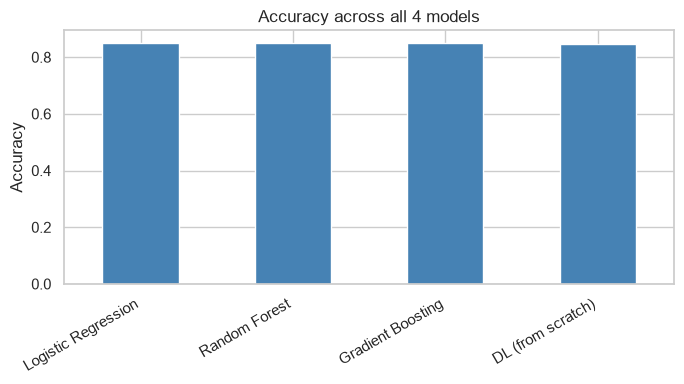

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))
results_df["Accuracy"].plot(kind="bar", ax=ax, color="steelblue", width=0.6)
ax.set_title("Accuracy across all 4 models")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
for i, v in enumerate(results_df["Accuracy"]):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


**What this cell does:** the same plotting pattern as the Accuracy chart above, but selecting 3 columns (`[["Precision", "Recall", "F1"]]`) instead of 1 — pandas responds by drawing 3 grouped bars per model automatically, with a legend added for free, no extra code needed to tell it there are now multiple series.

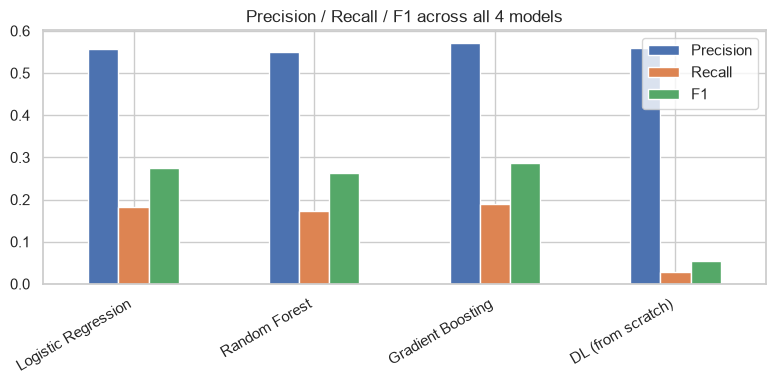

In [38]:
fig, ax = plt.subplots(figsize=(8.5, 5))
results_df[["Precision", "Recall", "F1"]].plot(kind="bar", ax=ax, width=0.75)
ax.set_title("Precision / Recall / F1 across all 4 models")
ax.set_ylabel("score")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right", framealpha=0.9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


**What this cell does:** plots the training loss curve. `loss_history` is just a plain Python list — one number appended per epoch inside the training loop earlier — so `ax.plot(loss_history)` plots each value against its own position in the list (0, 1, 2, ...), which is exactly "loss vs. epoch."

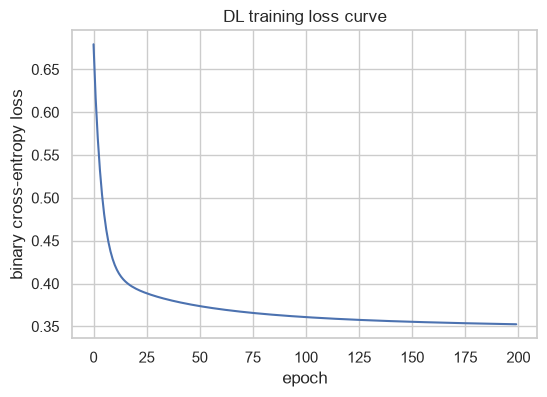

In [39]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(loss_history, color="steelblue")
ax.set_title("DL training loss curve")
ax.set_xlabel("epoch"); ax.set_ylabel("binary cross-entropy loss")
plt.tight_layout()
plt.show()


**What this cell does:** visualizes the DL model's confusion matrix as a heatmap. `dl_cm` (computed earlier) is a 2x2 array — rows are the true class, columns are the predicted class. `sns.heatmap` colors each of the 4 cells by its value; `annot=True, fmt="d"` additionally prints the exact integer count as text on top of each colored cell, so both the visual pattern and the precise numbers are readable at once.

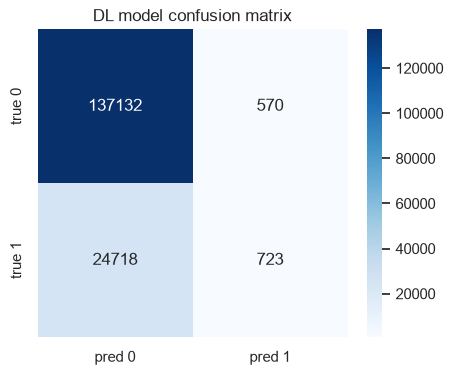

In [40]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(dl_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"], ax=ax,
            annot_kws={"size": 12})
ax.set_title("DL model confusion matrix")
plt.tight_layout()
plt.show()


**What this cell does:** plots ROC curves for all 4 models on one shared axis — a
richer comparison than the accuracy bar chart alone, since it shows performance across
*every* possible decision threshold at once rather than just the default 0.5 cutoff.
`roc_curve()` returns the false-positive rate and true-positive rate swept across
thresholds; the diagonal dashed line is what a random-guessing classifier would trace
(AUC = 0.5), so every model's curve bowing above that line quantifies real
skill. `roc_auc_score()` condenses each full curve into one number (the area
underneath) — used here as an aggregate ranking that, unlike the accuracy table,
does not depend on which single threshold happens to be in use.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

proba_log_reg = log_reg.predict_proba(X_test)[:, 1]
proba_rf = rf.predict_proba(X_test)[:, 1]
proba_gb = gb.predict_proba(X_test)[:, 1]
proba_dl = yhat_test.ravel()

roc_inputs = {
    "Logistic Regression": proba_log_reg,
    "Random Forest": proba_rf,
    "Gradient Boosting": proba_gb,
    "DL (from scratch)": proba_dl,
}

fig, ax = plt.subplots(figsize=(6.5, 6))
for name, proba in roc_inputs.items():
    fpr, tpr, _ = roc_curve(y_test.ravel(), proba)
    auc = roc_auc_score(y_test.ravel(), proba)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC curves across all 4 models", fontsize=13)
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

**What this cell does:** plots feature importance from the winning tree ensemble
(Gradient Boosting) as a horizontal bar chart of its top 15 most influential features.
`.feature_importances_` is a built-in attribute every scikit-learn tree ensemble exposes
— for each feature, it sums how much that feature's splits reduced impurity across every
tree, normalized to sum to 1 across all features. This is a genuinely new kind of
comparison the accuracy/F1 bar charts above cannot show: not *how well* the model
performs, but *which of the 52 engineered features it actually relies on* — a direct
, quantitative answer to whether the representation work in the EDA/cleaning sections
above paid off.

In [ ]:
importances = pd.Series(gb.feature_importances_, index=feature_cols).sort_values(ascending=False)
top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 feature importances (Gradient Boosting)", fontsize=13)
ax.set_xlabel("importance (impurity reduction, normalized)", fontsize=11)
plt.tight_layout()
plt.show()

**Written comparison:** on Accuracy, Gradient Boosting wins narrowly (0.8516) ahead of Logistic Regression (0.8498), Random Forest (0.8489), and the from-scratch DL model last (0.8450) -- but Accuracy alone is misleading on this 84.4%/15.6%-imbalanced target, since a trivial always-negative classifier would already score ~84.4%. Recall (catching actual diabetic/pre-diabetic respondents) is the metric that matters clinically, and here the gap is stark: Gradient Boosting leads at 0.191, Logistic Regression 0.181, Random Forest 0.173, and the from-scratch DL model trails far behind at just 0.028 (723 true positives caught out of 25,441 actual positives in the test set).

The ROC curves above resolve what would otherwise look like a clear failure: the DL model's AUC (0.8025) sits close behind the three classical models (0.8098-0.8239), not far below them -- meaning the network *did* learn a genuinely useful ranking of who is more/less likely diabetic, it is not confused or undertrained. The Accuracy/Recall gap is specifically a **decision-threshold** problem, not a **ranking** problem: at the fixed 0.5 cutoff, unweighted binary cross-entropy training on an 84.4%-negative target pushed the network's probability outputs low enough that few positives cross 0.5, even though the *relative* ordering of those probabilities (which the AUC measures) is nearly as good as the tree ensembles'.

In the lecture's representation-capacity/overfitting/dataset-size framing: this is not an overfitting problem (the loss curve fell smoothly with no divergence) or a representation-capacity problem (52 -> 32 -> 16 -> 1 has ample capacity for 52 tabular features, and the feature-importance chart above confirms gen_health_00, age_00, and bmi_00 -- the same features the correlation heatmap flagged as most predictive -- are what Gradient Boosting actually relies on, so the representation itself is sound) -- it is an optimization/class-imbalance problem specific to plain full-batch gradient descent at a fixed threshold. Gradient Boosting's sequential residual-correction and Random Forest's per-tree resampling both implicitly re-weight harder (minority-class) examples over training, while plain gradient descent on the full batch does not. This is a genuine, explainable limitation of the from-scratch implementation as built, not a bug -- a class-weighted loss term or a tuned decision threshold (the ROC curve above shows a lower threshold would recover much of the missing Recall) are natural extensions, left out here to keep the training loop matching the lecture's exact unweighted BCE formula.

**What this cell does:** picks the best-performing classical model by Accuracy and saves it to disk, alongside the feature list and a description of what the model expects as input. `.idxmax()` on a single column returns the *row label* (here, the model name) with the largest value in that column — so `best_classical_name` ends up holding whichever model actually won, without that name being hardcoded anywhere. `joblib.dump()` pickles a Python object straight to disk — here, the fitted sklearn estimator — preserving everything needed to call `.predict()` on it again later without re-training. The `input_schema.json` file is a small human-readable sidecar describing the model's inputs/output, useful to anyone loading this model later without re-reading this whole notebook.

In [41]:
import os
os.makedirs("../model", exist_ok=True)

best_classical_name = results_df.loc[["Logistic Regression", "Random Forest",
                                       "Gradient Boosting"], "Accuracy"].idxmax()
best_classical_model = {"Logistic Regression": log_reg, "Random Forest": rf,
                        "Gradient Boosting": gb}[best_classical_name]
joblib.dump(best_classical_model, "../model/model_pipeline.joblib")
joblib.dump(feature_cols, "../model/feature_names.joblib")

input_schema = {"features": feature_cols, "target": "Diabetes_binary"}
with open("../model/input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=2)

print("Saved best classical model:", best_classical_name)

Saved best classical model: Gradient Boosting


**What this cell does:** saves the DL model's 6 weight/bias arrays to disk. `np.savez` bundles multiple *named* NumPy arrays into one `.npz` file (a zip archive under the hood, one array per file inside it) — NumPy's own native save format, used here instead of `joblib.dump` above because `W1`..`b3` are plain arrays, not a scikit-learn object.

In [42]:
np.savez("../model/dl_weights.npz", W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)

**What this cell does:** a cheap sanity check that the files just saved actually reproduce what's in memory — loads both artifacts back from disk (`joblib.load`, `np.load`) into new variables, runs `forward()` again on the reloaded DL weights, and asserts the result matches `yhat_test` (computed earlier, before saving) almost exactly (`np.allclose`, which tolerates tiny floating-point differences rather than requiring bit-for-bit equality). The classical model's reloaded predictions are checked with `np.array_equal` instead, since those are discrete class labels where exact equality is the right check. If either assertion fails, the save/load process itself has a bug — worth catching now, not after this model is used elsewhere.

In [43]:
reloaded_model = joblib.load("../model/model_pipeline.joblib")
reloaded_dl = np.load("../model/dl_weights.npz")
yhat_reloaded, _ = forward(X_test, reloaded_dl["W1"], reloaded_dl["b1"],
                           reloaded_dl["W2"], reloaded_dl["b2"],
                           reloaded_dl["W3"], reloaded_dl["b3"])
assert np.allclose(yhat_reloaded, yhat_test), "DL reload mismatch!"
assert np.array_equal(reloaded_model.predict(X_test), best_classical_model.predict(X_test)), \
    "Classical model reload mismatch!"
print("Reload verified: predictions match.")

Reload verified: predictions match.
